In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_long = pd.read_csv('df_long.csv')
# pd.set_option('display.max_columns', None)
# display(df_long)
print(df_long)

       iid  gender  condtn  wave  round  position  order  partner    pid  \
0        1       0       1     1     10         7      1        7   17.0   
1        1       0       1     1     10         7      1        7   17.0   
2        1       0       1     1     10         7      1        7   17.0   
3        1       0       1     1     10         7      1        7   17.0   
4        1       0       1     1     10         7      1        7   17.0   
...    ...     ...     ...   ...    ...       ...    ...      ...    ...   
37885  552       1       2    21     22        18      9        8  516.0   
37886  552       1       2    21     22        18      9        8  516.0   
37887  552       1       2    21     22        18      9        8  516.0   
37888  552       1       2    21     22        18      9        8  516.0   
37889  552       1       2    21     22        18      9        8  516.0   

       match  ...  length  numdat_2    amb   attr    fun  intel   shar   sinc  \
0     

In [3]:
print(f"df_long.shape:\n{df_long.shape}\n")
print(f"df_long.columns.tolist():\n{df_long.columns.tolist()}\n")

df_long.shape:
(37890, 75)

df_long.columns.tolist():
['iid', 'gender', 'condtn', 'wave', 'round', 'position', 'order', 'partner', 'pid', 'match', 'int_corr', 'samerace', 'age_o', 'race_o', 'pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha', 'dec_o', 'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o', 'like_o', 'prob_o', 'met_o', 'age', 'field', 'race', 'imprace', 'imprelig', 'from', 'zipcode', 'goal', 'date', 'go_out', 'career', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'exphappy', 'dec', 'like', 'prob', 'met', 'match_es', 'satis_2', 'length', 'numdat_2', 'amb', 'attr', 'fun', 'intel', 'shar', 'sinc', 'pre_post', 'rating_ref_group']



In [4]:
print(f"df_long.describe():\n{df_long.describe()}\n")
print(f"df_long.info():\n{df_long.info()}\n")

df_long.describe():
                iid        gender        condtn          wave         round  \
count  37890.000000  37890.000000  37890.000000  37890.000000  37890.000000   
mean     322.898021      0.477012      1.874690     12.844339     17.250356   
std      152.124991      0.499478      0.331075      5.775174      4.306776   
min        1.000000      0.000000      1.000000      1.000000      5.000000   
25%      211.000000      0.000000      2.000000      9.000000     15.000000   
50%      319.000000      0.000000      2.000000     12.000000     18.000000   
75%      455.000000      1.000000      2.000000     18.000000     21.000000   
max      552.000000      1.000000      2.000000     21.000000     22.000000   

           position         order       partner           pid         match  \
count  37890.000000  37890.000000  37890.000000  37890.000000  37890.000000   
mean       9.191581      8.980602      9.264529    323.744392      0.172447   
std        5.493806      5.5128

## Autoencoder & Mixed-Effects Model EDA

### Hierarchical & Grouping Structure (for Mixed Effects Model)

In [5]:
print(f"Unique Subjects (iid): {df_long['iid'].nunique()}")
print(f"Unique Partners (pid): {df_long['pid'].nunique()}")
print(f"Unique Waves/Events (wave): {df_long['wave'].nunique()}")

obs_per_subject = df_long.groupby('iid').size()
obs_per_partners = df_long.groupby('pid').size()
print(f"Observations per subject (iid):")
print(f"Min: {obs_per_subject.min()}, Max: {obs_per_subject.max()}, Mean: {obs_per_subject.mean():.2f}, Median: {obs_per_subject.median():.2f}\n")
print(f"Observations per partners (pid):")
print(f"Min: {obs_per_partners.min()}, Max: {obs_per_partners.max()}, Mean: {obs_per_partners.mean():.2f}, Median: {obs_per_partners.median():.2f}\n")

waves_per_subject = df_long.groupby('iid')['wave'].nunique()
waves_per_partners = df_long.groupby('pid')['wave'].nunique()
print(f"Max waves attended per subject: {waves_per_subject.max()}")
print(f"Max waves attended per partners: {waves_per_partners.max()}")
#If iid and pid each have only 1 unique value per wave (Max =1), they are nested within wave. 
#They cannot act as crossed random effects, as crossed structures occur when variables are independent and cross-classify across each other
#Crossed random effects require units to exist across multiple levels of another grouping factor (example: if the same iid was observed in multiple different waves)

Unique Subjects (iid): 362
Unique Partners (pid): 503
Unique Waves/Events (wave): 20
Observations per subject (iid):
Min: 10, Max: 231, Mean: 104.67, Median: 100.00

Observations per partners (pid):
Min: 5, Max: 187, Mean: 75.33, Median: 70.00

Max waves attended per subject: 1
Max waves attended per partners: 1


### Missing Data (Address for Autoencoder)

In [6]:
missing_pct = df_long.isnull().mean() * 100
missing_cols = missing_pct[missing_pct > 0].sort_values(ascending=False)
if not missing_cols.empty:
    print(missing_cols.apply(lambda x: f"{x:.2f}%"))
else:
    print("No missing values found.")

shar    36.95%
amb      0.06%
sinc     0.06%
attr     0.04%
dtype: object


In [7]:
# High cardinality needs entity embeddings; low cardinality needs one-hot encoding.
cat_cols = df_long.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    unique_count = df_long[col].nunique()
    rec = "Use One-Hot" if unique_count < 10 else "Use Embedding Layer / Drop"
    print(f"{col}: {unique_count} unique values ({rec})")

field: 190 unique values (Use Embedding Layer / Drop)
from: 193 unique values (Use Embedding Layer / Drop)
zipcode: 324 unique values (Use Embedding Layer / Drop)
career: 266 unique values (Use Embedding Layer / Drop)
pre_post: 2 unique values (Use One-Hot)
rating_ref_group: 6 unique values (Use One-Hot)


### Numeric Variance & Scales (Use this for autoencoder loss)

In [8]:
num_cols = df_long.select_dtypes(include=[np.number]).columns.tolist() #only numeric values
ids_and_structure = ['iid', 'pid', 'partner', 'wave', 'round', 'position', 'order']
features_to_check = []
for col in num_cols:
    if col not in ids_and_structure:
        features_to_check.append(col)

stats_df = df_long[features_to_check].agg(['min', 'max', 'var']).T

zero_var = stats_df[stats_df['var'] == 0].index.tolist() # zero variance features -> pure noise for an autoencoder
if zero_var:
    print(f"Features with Zero Variance (Drop these):\n{zero_var}\n")
else:
    print(f"Zero Variance Features? -> None found ") # (all features have some variance though some could be marginal)

# show top features that will disproportionately affect MSE
print(f"\nTop 5 Highest Variance Features (Critical to Scale):\n{stats_df.sort_values(by='var', ascending=False).head(5)}")

Zero Variance Features? -> None found 

Top 5 Highest Variance Features (Critical to Scale):
          min    max         var
attr      0.0  100.0  244.816073
pf_o_att  0.0  100.0  153.065905
pf_o_sin  0.0   47.0   53.985710
fun       0.0   50.0   53.417087
pf_o_int  0.0   50.0   49.470584


# My Code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss
from tqdm.notebook import tqdm
# import statsmodels.formula.api as smf #LME model
# from scipy.stats import chi2
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('df_long.csv')
print(f"Initial shape: {df.shape}")

id_cols = ['iid', 'pid', 'partner', 'wave', 'round', 'position', 'order'] #indentify ppl
decision_cols = ['dec', 'dec_o'] #including them would make match perfectly predictable
high_card_cols = ['field', 'from', 'zipcode', 'career'] # highly cardinal -> lot of unique vals
shar_features = ['shar', 'shar_o']  #shar has 36.95% of values missing -> don't want to median impute 
outcome_col = 'match'

drop_cols = id_cols + decision_cols + high_card_cols + shar_features
ids = df[['iid', 'pid']].copy()
y = df[outcome_col].values

cat_cols_encode = ['pre_post', 'rating_ref_group']
df_encoded = pd.get_dummies(df[cat_cols_encode], drop_first=True).astype(float)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove columns that we are dropping
feature_numeric = []
for c in numeric_cols:
    if c not in drop_cols and c != outcome_col:
        feature_numeric.append(c)
        
X_numeric = df[feature_numeric].astype(float)

X = pd.concat([X_numeric, df_encoded], axis=1)
feature_names = X.columns.tolist()
print(f"Number of features post dropping: {len(feature_names)}")

Initial shape: (37890, 75)
Number of features post dropping: 63


In [2]:
# len(X_train_raw.columns)

In [3]:
unique_iids = df['iid'].unique() #Split data by subject (iid) to avoid leakage
temp_train_iids, test_iids = train_test_split(unique_iids, test_size=0.2, random_state=28) #20% Test, 80% Temp_Train
train_iids, val_iids = train_test_split(temp_train_iids, test_size=0.1, random_state=10) #10% of the 80% Temp_Train goes to Validation

train_idx = df['iid'].isin(train_iids)
val_idx = df['iid'].isin(val_iids)
test_idx = df['iid'].isin(test_iids)

X_train_raw = X[train_idx].copy()
X_val_raw = X[val_idx].copy()
X_test_raw = X[test_idx].copy()

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]
ids_train = ids[train_idx]
ids_val = ids[val_idx]
ids_test = ids[test_idx]

print(f"Train size: {X_train_raw.shape[0]} ({(X_train_raw.shape[0]/df.shape[0])*100:.1f}%), Val size: {X_val_raw.shape[0]} ({(X_val_raw.shape[0]/df.shape[0])*100:.1f}%), Test size: {X_test_raw.shape[0]} ({(X_test_raw.shape[0]/df.shape[0])*100:.1f}%)")

Train size: 26974 (71.2%), Val size: 3414 (9.0%), Test size: 7502 (19.8%)


In [4]:
# X_train_raw.columns.tolist()

In [5]:
# compute medians ONLY on training data to prevent leakage
medians = X_train_raw.median()
X_train_imp = X_train_raw.fillna(medians)
X_val_imp = X_val_raw.fillna(medians)
X_test_imp = X_test_raw.fillna(medians)

# scale based ONLY on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

print(f"Scaled training features shape: {X_train_scaled.shape}")

Scaled training features shape: (26974, 63)


In [6]:
# X_train_imp[['age_o']]

In [7]:
# pd.DataFrame(X_train_scaled)[[1]].std()

## Autoencoder w/ Dropout & BatchNormalization

In [8]:
#Autoencoder definition (from pytorch web) with Dropout and Batch Normalization
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8, dropout_rate=0.20):
        super(Autoencoder, self).__init__()
        # Encoder: Smoothly bottlenecks without blowing up layer capacity
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 48),
            nn.BatchNorm1d(48),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(48, 24),
            nn.BatchNorm1d(24),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(24, latent_dim)  # Bottleneck
        )
        # Decoder: Reconstructs the compressed representations back to input_dim
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 24),
            nn.BatchNorm1d(24),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(24, 48),
            nn.BatchNorm1d(48),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(48, input_dim)
        )
        
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z



latent_dim = 8
input_dim = X_train_scaled.shape[1]
batch_size = 256
learning_rate = 0.001
num_epochs = 500
patience = 15

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_val_tensor = torch.FloatTensor(X_val_scaled)
train_dataset = TensorDataset(X_train_tensor, X_train_tensor) #autoencoder uses input as target
val_dataset = TensorDataset(X_val_tensor, X_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

model = Autoencoder(input_dim, latent_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [15]:
best_val_loss = np.inf
patience_counter = 0
best_model_state = None
loss_history = {'train_loss': [], 'val_loss': []}
# training model
for epoch in tqdm(range(num_epochs)):
    model.train()
    train_loss = 0.0
    for batch_x, _ in train_loader:
        optimizer.zero_grad()
        recon, _ = model(batch_x)
        loss = criterion(recon, batch_x)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    train_loss /= len(train_loader.dataset)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, _ in val_loader:
            recon, _ = model(batch_x)
            loss = criterion(recon, batch_x)
            val_loss += loss.item() * batch_x.size(0)
    val_loss /= len(val_loader.dataset)
    
    loss_history['train_loss'].append(train_loss)
    loss_history['val_loss'].append(val_loss)
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)


  0%|          | 0/500 [00:00<?, ?it/s]

Epoch  20 | Train Loss: 0.754584 | Val Loss: 0.730051
Epoch  40 | Train Loss: 0.738891 | Val Loss: 0.726731
Epoch  60 | Train Loss: 0.732455 | Val Loss: 0.727713
Early stopping at epoch 67


<All keys matched successfully>

In [18]:
torch.save(model.state_dict(), 'best_model.pth')
np.save('loss_history.npy', loss_history)

In [9]:
loss_history = np.load('loss_history.npy', allow_pickle=True).item()

In [10]:
print(f"loss_history['train_loss']:\n{loss_history['train_loss']}\n")
print(f"loss_history['val_loss']:\n{loss_history['val_loss']}\n")

loss_history['train_loss']:
[0.9911582991696274, 0.8737981132000117, 0.8339907607580032, 0.8106959008247758, 0.7970357265563982, 0.788305514364553, 0.7815621854633683, 0.7773380917969649, 0.7735963450613409, 0.7703447687605556, 0.7679305701725317, 0.7659246562108317, 0.7634598325479196, 0.7617965015080239, 0.7590002341108519, 0.758252238448594, 0.7578032633748624, 0.7559707952922805, 0.755761410128136, 0.7545838601295577, 0.753471421074671, 0.7522220885973718, 0.7515376078116405, 0.7513192482615821, 0.7515440832881796, 0.749704374083156, 0.7492156211843906, 0.7485492998660782, 0.7469616076816681, 0.747173232826105, 0.7456777775810003, 0.7460735855193049, 0.7447932192541578, 0.7444475318394342, 0.7430112588491345, 0.7428983272584805, 0.7413614182402579, 0.7411944017078292, 0.7396353391055279, 0.7388905645601213, 0.7395784725134903, 0.7387743821806663, 0.7387241048297386, 0.7370587601542888, 0.7371985892258855, 0.7367765707692834, 0.7363343712459229, 0.7345078635084945, 0.735295894820014

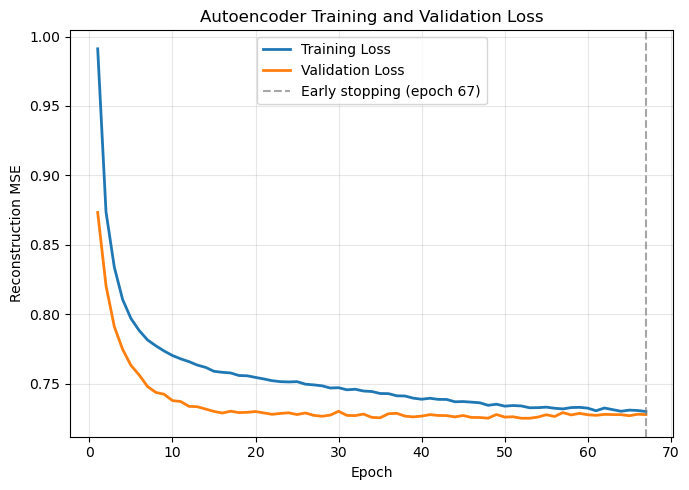

In [86]:
import matplotlib.pyplot as plt
import numpy as np

train_loss = loss_history['train_loss']
val_loss = loss_history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, train_loss, label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)
plt.axvline(x=stop_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Early stopping (epoch {67})')

plt.xlabel('Epoch')
plt.ylabel('Reconstruction MSE')
plt.title('Autoencoder Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure_autoencoder_loss.png', dpi=300)
plt.show()

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
saved_weights = torch.load('best_model.pth', map_location=device)
model.load_state_dict(saved_weights)
model.to(device)
model.eval()

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=63, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=48, out_features=24, bias=True)
    (5): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=24, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=24, bias=True)
    (1): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=24, out_features=48, bias=True)
    (5): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=48, out_features=63, bias=True)

In [13]:
#extract latent features for all data
model.eval()
X_train_tensor_full = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

with torch.no_grad():
    _, Z_train = model(X_train_tensor_full)
    _, Z_test = model(X_test_tensor)

Z_train = Z_train.numpy()
Z_test = Z_test.numpy()

latent_cols = []
for i in range(latent_dim):
    latent_cols.append(f'Z{i+1}')

## Mixed-Effects/Clustered Model

In [14]:
df_train_mixed = pd.DataFrame(Z_train, columns=latent_cols)
df_train_mixed['match'] = y_train
df_train_mixed['gender'] = df.loc[train_idx, 'gender'].values  
df_train_mixed['iid'] = df.loc[train_idx, 'iid'].values
print(f"df_train_mixed:\n{df_train_mixed}\n")
# print("df_train_mixed:")
# display(df_train_mixed)

df_test_mixed = pd.DataFrame(Z_test, columns=latent_cols)
df_test_mixed['match'] = y_test
df_test_mixed['gender'] = df.loc[test_idx, 'gender'].values
df_test_mixed['iid'] = df.loc[test_idx, 'iid'].values
print(f"df_test_mixed:\n{df_test_mixed}")
# print("\ndf_test_mixed:")
# display(df_test_mixed)

df_train_mixed:
             Z1        Z2        Z3        Z4        Z5        Z6        Z7  \
0      2.034090  0.348345 -0.481345 -0.031190  1.302202 -1.258625 -0.467085   
1      1.736145  0.341677 -0.386028 -0.141184  1.107147 -0.919867 -0.192172   
2      0.529805  0.191925 -0.274319 -0.409653  0.602071  0.347756  0.595307   
3      0.092927  0.135315 -0.224349 -0.514375  0.429986  0.806529  0.862857   
4      0.091262  0.141203 -0.206600 -0.514063  0.428810  0.817708  0.863970   
...         ...       ...       ...       ...       ...       ...       ...   
26969  0.112139 -0.817831 -0.526198 -0.150622  0.161755 -0.286848  0.508394   
26970  0.044156 -0.827776 -0.534044 -0.146594  0.158713 -0.220679  0.581338   
26971 -0.036614 -0.819692 -0.520967 -0.148530  0.132269 -0.101530  0.671878   
26972 -0.018640 -0.803592 -0.478326 -0.147107  0.116939 -0.104276  0.700896   
26973  0.326906 -0.705456 -0.294285 -0.098760  0.122690 -0.247183  0.713004   

             Z8  match  gender  iid

In [18]:
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

# Prepare formula (same latent features, main effects, gender, interactions)
main_effects = ' + '.join(latent_cols)
interaction_terms = ' + '.join([f'gender:{col}' for col in latent_cols])
formula = f"match ~ {main_effects} + gender + {interaction_terms}"

print(f"Model formula: {formula}")

Model formula: match ~ Z1 + Z2 + Z3 + Z4 + Z5 + Z6 + Z7 + Z8 + gender + gender:Z1 + gender:Z2 + gender:Z3 + gender:Z4 + gender:Z5 + gender:Z6 + gender:Z7 + gender:Z8


In [19]:
df_train_mixed['iid_cat'] = df_train_mixed['iid'].astype(str)
df_test_mixed['iid_cat'] = df_test_mixed['iid'].astype(str)

In [37]:
import statsmodels.formula.api as smf
melpm_model = sm.MixedLM.from_formula( # Mixed Effects Linear Probability Model MELPM
    formula, 
    groups='iid', 
    data=df_train_mixed
).fit()
print(melpm_model.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: match     
No. Observations: 26974   Method:             REML      
No. Groups:       260     Scale:              0.1042    
Min. group size:  10      Log-Likelihood:     -8433.0626
Max. group size:  231     Converged:          Yes       
Mean group size:  103.7                                 
--------------------------------------------------------
             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     0.173    0.033   5.287 0.000  0.109  0.238
Z1           -0.027    0.010  -2.620 0.009 -0.046 -0.007
Z2            0.562    0.022  25.571 0.000  0.519  0.606
Z3           -0.210    0.019 -11.074 0.000 -0.248 -0.173
Z4           -0.446    0.028 -15.908 0.000 -0.501 -0.391
Z5           -0.338    0.017 -20.301 0.000 -0.370 -0.305
Z6           -0.223    0.018 -12.498 0.000 -0.258 -0.188
Z7            0.009    0.014   0.668 0.50

In [38]:
# For your first model (melpm_model)
print(f"MELPM AIC: {melpm_model.aic}")
print(f"MELPM BIC: {melpm_model.bic}")

MELPM AIC: nan
MELPM BIC: nan


In [35]:
vc_formulas = {"iid": "0 + C(iid_cat)"}

melr = BinomialBayesMixedGLM.from_formula( # Mixed-Effects Logistic Regression
    formula,
    vc_formulas=vc_formulas,
    data=df_train_mixed
).fit_map() # MAP estimation for point estimates

print(melr.summary())

               Binomial Mixed GLM Results
          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------
Intercept    M    -2.0624   0.3206                      
Z1           M     0.7166   0.1074                      
Z2           M     4.3202   0.2333                      
Z3           M     2.6206   0.3203                      
Z4           M    -2.9428   0.2834                      
Z5           M    -2.8912   0.1784                      
Z6           M    -0.8229   0.1822                      
Z7           M    -1.0271   0.1520                      
Z8           M     1.5425   0.2031                      
gender       M    -2.1666   0.4621                      
gender:Z1    M    -0.8422   0.1624                      
gender:Z2    M    -0.0129   0.3139                      
gender:Z3    M    -4.0552   0.3940                      
gender:Z4    M     1.3191   0.3873                      
gender:Z5    M     0.1901   0.2801            

In [26]:
# #fitting models: GEE model with a Binomial logit link, clustered at the participant level (iid) & null baseline model
# mixed_model = sm.GEE.from_formula(
#     formula, 
#     groups=df_train_mixed['iid'], 
#     data=df_train_mixed, 
#     family=sm.families.Binomial()
# )
# result = mixed_model.fit()
# print(result.summary())

# # Fit null model for baseline comparison
# null_model = sm.GEE.from_formula(
#     "match ~ 1", 
#     groups=df_train_mixed['iid'], 
#     data=df_train_mixed, 
#     family=sm.families.Binomial()
# )
# null_result = null_model.fit()
# print(f"\n\n{null_result.summary()}")

In [84]:
# ## THESE MAY BE IRRELAVANT:
# # predict probabilities directly on the test set
# test_pred = result.predict(df_test_mixed)
# auc = roc_auc_score(df_test_mixed['match'], test_pred)
# brier = brier_score_loss(df_test_mixed['match'], test_pred)
# print(f"Test ROC-AUC: {auc:.4f}\nTest Brier score: {brier:.4f}\n")

# # Baseline ROC-AUC using only the intercept
# null_test_pred = null_result.predict(df_test_mixed)
# baseline_auc = roc_auc_score(df_test_mixed['match'], null_test_pred)
# baseline_brier = brier_score_loss(df_test_mixed['match'], test_pred)
# print(f"Null model Test ROC-AUC: {baseline_auc:.4f}\nNull model Test Brier score: {baseline_brier:.4f}")

# delta_auc = auc - baseline_auc
# delta_brier = brier - baseline_brier
# print(f"\nAUC Improvement (Full AUC - Null AUC): {delta_auc:.3f}")
# print(f"Brier Improvement (Full Brier - Null Brier): {delta_brier:.3f}")

In [43]:
#Post-hoc correlation of latent features with original feature
corr_matrix = np.corrcoef(np.hstack([X_train_scaled, Z_train]).T)
p = X_train_scaled.shape[1]
latent_corrs = corr_matrix[:p, p:]# rows: original features, cols: latent features
corr_df = pd.DataFrame(latent_corrs, index=feature_names, columns=latent_cols)

In [44]:
print(corr_df)

                                          Z1        Z2        Z3        Z4  \
gender                             -0.299490 -0.281654 -0.248135 -0.431762   
condtn                              0.020712 -0.010356 -0.046539 -0.053110   
int_corr                            0.042281 -0.102422  0.138136  0.131144   
samerace                            0.041804  0.036169  0.110146 -0.010351   
age_o                               0.035424 -0.003274  0.037437  0.058663   
...                                      ...       ...       ...       ...   
rating_ref_group_othersex_value    -0.116177 -0.017321  0.008559 -0.038257   
rating_ref_group_samesex_value     -0.114221 -0.011016  0.010159 -0.028880   
rating_ref_group_self_rating       -0.328562 -0.045807  0.063739 -0.124497   
rating_ref_group_self_value         0.665871  0.055923 -0.096380  0.200588   
rating_ref_group_self_valuing_post  0.023269  0.027232  0.024990  0.025777   

                                          Z5        Z6        Z

In [80]:
print(corr_df.describe())

              Z1         Z2         Z3         Z4         Z5         Z6  \
count  63.000000  63.000000  63.000000  63.000000  63.000000  63.000000   
mean    0.034722   0.107403   0.005277   0.074943  -0.027304  -0.018967   
std     0.190959   0.194810   0.210474   0.212214   0.176512   0.186124   
min    -0.328562  -0.281654  -0.456181  -0.504880  -0.334618  -0.702325   
25%    -0.104425  -0.028007  -0.096795  -0.035279  -0.146550  -0.117102   
50%     0.035424   0.059467  -0.013454   0.060584  -0.071213  -0.011943   
75%     0.148641   0.296673   0.101063   0.173552   0.051621   0.094517   
max     0.665871   0.433555   0.541898   0.577361   0.417946   0.373119   

              Z7         Z8  
count  63.000000  63.000000  
mean   -0.047616   0.078936  
std     0.192773   0.185633  
min    -0.559188  -0.358239  
25%    -0.143130  -0.033226  
50%    -0.037461   0.071945  
75%     0.096104   0.199535  
max     0.246191   0.489148  


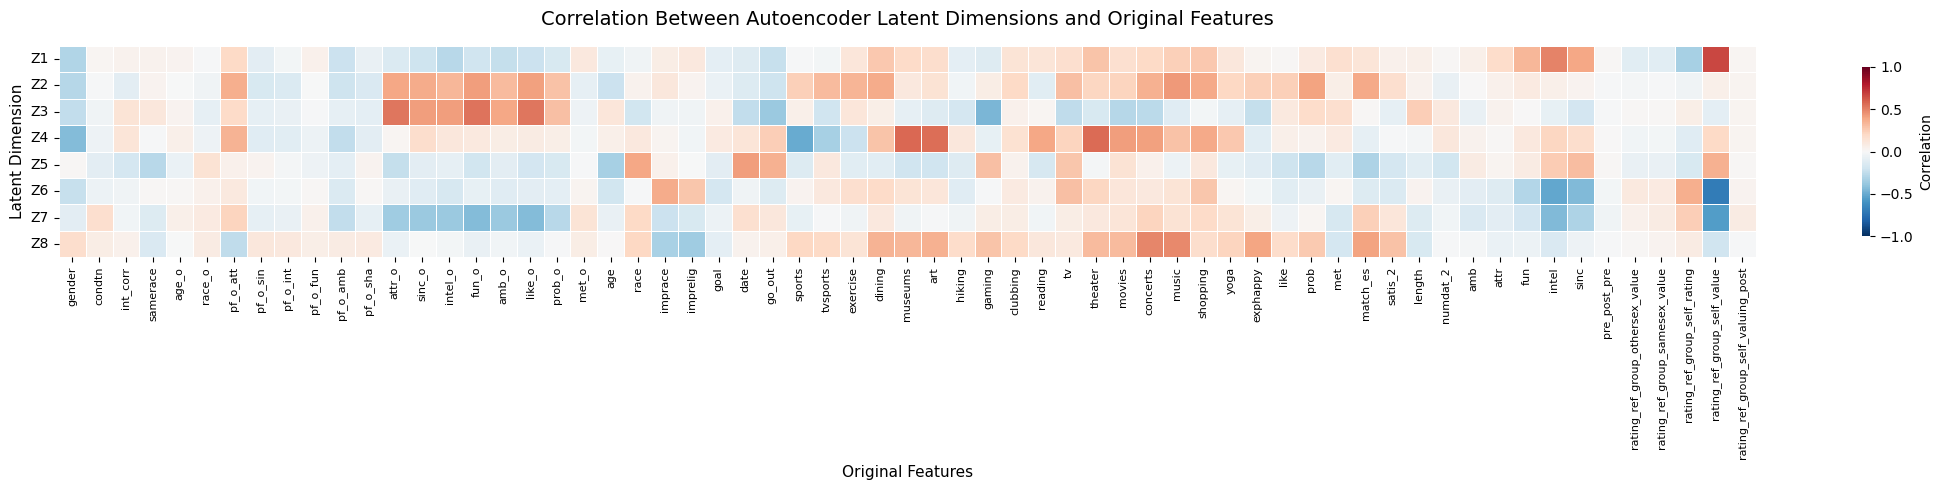

In [90]:
corr_df_transposed = corr_df.T

plt.figure(figsize=(22, 5))
heatmap = sns.heatmap(
    corr_df_transposed,
    cmap='RdBu_r',       # red for positive, blue for negative
    vmin=-1, vmax=1, center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)
plt.title('Correlation Between Autoencoder Latent Dimensions and Original Features',
          fontsize=14, pad=15)
plt.xlabel('Original Features', fontsize=11)
plt.ylabel('Latent Dimension', fontsize=11)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('figure_latent_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
print("Top correlations of each latent dimension (Original Signs):")
for col in latent_cols:
    top5_idx = corr_df[col].abs().sort_values(ascending=False).head(5).index
    top5_original = corr_df.loc[top5_idx, col]
    print(f"\n{col}:")
    for feature, value in top5_original.items():
        print(f"{feature:<35} {value:+.6f}")

Top correlations of each latent dimension (Original Signs):

Z1:
rating_ref_group_self_value         +0.665871
intel                               +0.494353
sinc                                +0.384374
fun                                 +0.329987
rating_ref_group_self_rating        -0.328562

Z2:
music                               +0.433555
fun_o                               +0.420854
like_o                              +0.412827
prob                                +0.400075
attr_o                              +0.387567

Z3:
fun_o                               +0.541898
attr_o                              +0.532875
like_o                              +0.531730
gaming                              -0.456181
intel_o                             +0.420219

Z4:
museums                             +0.577361
theater                             +0.564961
art                                 +0.562210
sports                              -0.504880
gender                              -0.431762


## Model Evaluation

In [74]:
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score, log_loss
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

#### Autoencoder

In [57]:
input_dim = X_test_scaled.shape[1]  # 63 from earlier preprocessing
latent_dim = 8
model = Autoencoder(input_dim, latent_dim).to(device)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
with torch.no_grad():
    X_recon, Z_test_tensor = model(X_test_tensor)
    recon_errors = torch.mean((X_test_tensor - X_recon) ** 2, dim=1).cpu().numpy()

mse_test = np.mean(recon_errors)
print(f"Autoencoder Test MSE: {mse_test:.6f}")

recon_df = pd.DataFrame({'recon_error': recon_errors, 'true_match': y_test})
print("\nMean Reconstruction Error by Match:")
print(recon_df.groupby('true_match')['recon_error'].describe())

pd.Series(recon_errors, name='recon_error').to_csv('recon_errors_test.csv', index=False)
print(f"\nrecon_errors:\n{pd.Series(recon_errors, name='recon_error')}")

Autoencoder Test MSE: 0.703134

Mean Reconstruction Error by Match:
             count      mean       std       min       25%       50%  \
true_match                                                             
0           6141.0  0.702244  0.434741  0.285845  0.530531  0.651559   
1           1361.0  0.707147  0.254770  0.297319  0.514598  0.670488   

                 75%        max  
true_match                       
0           0.801214  11.139068  
1           0.840323   1.980452  

recon_errors:
0       0.695676
1       0.674238
2       0.841790
3       0.625720
4       0.628488
          ...   
7497    0.603352
7498    0.700387
7499    0.483458
7500    0.484052
7501    1.008365
Name: recon_error, Length: 7502, dtype: float32


#### Statistical Models

In [58]:
melpm_linear = melpm_model.predict(df_test_mixed) # linear predictor
melpm_probs = np.clip(melpm_linear, 0, 1) # ensure [0,1]

melpm_auc = roc_auc_score(y_test, melpm_probs)
melpm_brier = brier_score_loss(y_test, melpm_probs)
melpm_acc = accuracy_score(y_test, melpm_probs >= 0.5)
melpm_logloss = log_loss(y_test, melpm_probs)

print(f"AUC-ROC: {melpm_auc:.4f}")
print(f"Brier Score: {melpm_brier:.4f}")
print(f"Accuracy (0.5): {melpm_acc:.4f}")
print(f"Log Loss: {melpm_logloss:.4f}")

AUC-ROC: 0.6810
Brier Score: 0.1575
Accuracy (0.5): 0.7954
Log Loss: 1.6499


In [78]:
import patsy

_, X_test_design = patsy.dmatrices(formula, df_test_mixed, return_type='dataframe')
print(f"X_test_design.columns:\n{X_test_design.columns.tolist()}\n")

beta = melr.fe_mean
print(f"beta (beta.shape = {beta.shape}):\n{beta}\n")

linear_pred = X_test_design.values @ beta
melr_probs = 1 / (1 + np.exp(-linear_pred))

melr_auc = roc_auc_score(y_test, melr_probs)
melr_brier = brier_score_loss(y_test, melr_probs)
melr_acc = accuracy_score(y_test, melr_probs >= 0.5)
melr_logloss = log_loss(y_test, melr_probs)

print(f"AUC-ROC: {melr_auc:.4f}")
print(f"Brier: {melr_brier:.4f}")
print(f"Accuracy: {melr_acc:.4f}")
print(f"Log Loss: {melr_logloss:.4f}")

X_test_design.columns:
['Intercept', 'Z1', 'Z2', 'Z3', 'Z4', 'Z5', 'Z6', 'Z7', 'Z8', 'gender', 'gender:Z1', 'gender:Z2', 'gender:Z3', 'gender:Z4', 'gender:Z5', 'gender:Z6', 'gender:Z7', 'gender:Z8']

beta (beta.shape = (18,)):
[-2.06238331  0.71661201  4.32024073  2.62061589 -2.94280184 -2.89120317
 -0.82291015 -1.02711075  1.54253213 -2.16656149 -0.84221168 -0.01294186
 -4.05517416  1.31910914  0.19014535 -0.4402803   1.03654715 -0.40169702]

AUC-ROC: 0.7028
Brier: 0.1590
Accuracy: 0.8083
Log Loss: 0.5949


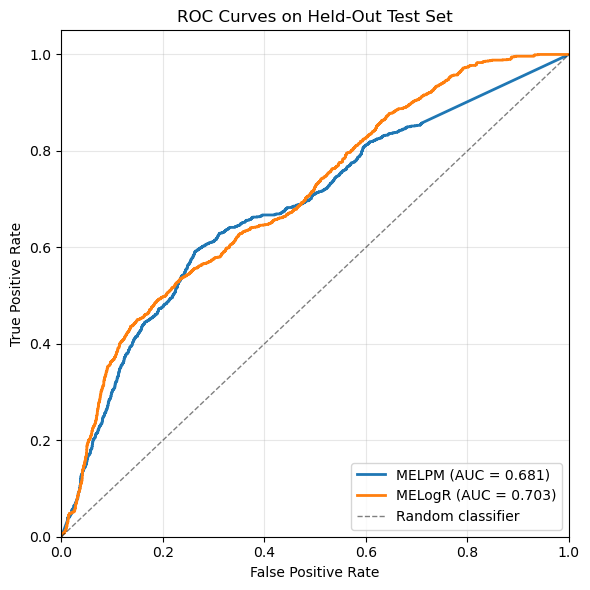

In [87]:
from sklearn.metrics import roc_curve, auc

fpr_pm, tpr_pm, _ = roc_curve(y_test, melpm_probs)
roc_auc_pm = auc(fpr_pm, tpr_pm)

fpr_lr, tpr_lr, _ = roc_curve(y_test, melr_probs)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6, 6))
plt.plot(fpr_pm, tpr_pm, linewidth=2, label=f'MELPM (AUC = {roc_auc_pm:.3f})')
plt.plot(fpr_lr, tpr_lr, linewidth=2, label=f'MELogR (AUC = {roc_auc_lr:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on Held‑Out Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figure_roc_comparison.png', dpi=300)
plt.show()